/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


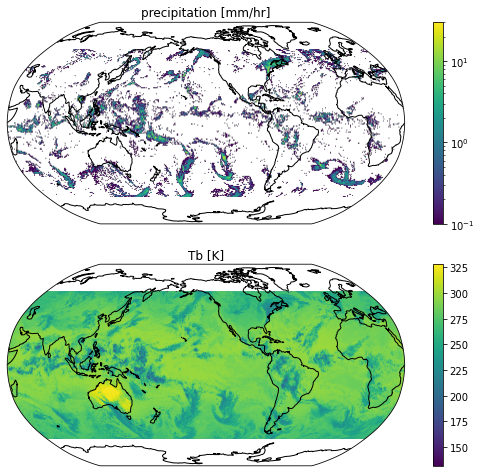

In [6]:
import cartopy.crs as ccrs
import easygems.healpix as egh
import intake
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
mpl.rcParams['figure.dpi'] = 72

import intake
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']
ds = cat['IR_IMERG'].to_dask()
# time in ['2019-01-01 00:00', '2021-12-31 23:00']
time = '2019-11-01 02:00'
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 8), subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})
def egh_plot(data, ax, **kwargs):
    ax.set_title(f'{data.name} [{data.attrs["units"]}]')
    ax.set_global()
    im = egh.healpix_show(data, ax=ax, **kwargs)
    plt.colorbar(im, ax=ax)
    ax.coastlines()

egh_plot(ds.precipitation.sel(time=time), ax=ax0, norm=mpl.colors.LogNorm(vmin=10e-2, vmax=30))
egh_plot(ds.Tb.sel(time=time), ax=ax1)

In [3]:
cat['IR_IMERG']

IR_IMERG:
  args:
    consolidated: true
    urlpath: http://hackathon-o.s3.jc.rl.ac.uk/obs-data/dev/v1/IR_IMERG_combined/IR_IMERG_combined_V07B.hp_z9.zarr
  description: ''
  driver: intake_xarray.xzarr.ZarrSource
  metadata:
    BeginDate: '2019-01-01'
    BeginTime: 00:00:00.000Z
    EndDate: '2019-01-01'
    EndTime: 00:59:59.999Z
    FileHeader: 'StartGranuleDateTime=2019-01-01T00:00:00.000Z;

      StopGranuleDateTime=2019-01-01T00:59:59.999Z'
    InputPointer: merg_2019010100_4km-pixel
    NCO: netCDF Operators version 5.2.4 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco,
      Citation = 10.1016/j.envsoft.2008.03.004)
    ProductionTime: '2019-01-03T19:22:29.342Z'
    catalog_dir: https://raw.githubusercontent.com/digital-earths-global-hackathon/catalog/refs/heads/add-healpix-IR-IMERG/UK
    coords: !!python/tuple
    - cell
    - crs
    - time
    data_vars:
      Tb:
      - cell
      - crs
      - time
      precipitation:
      - cell
      - crs
      - 

In [7]:
cat['um_Africa_km4p4_RAL3P3_n1280_GAL9_nest'].urlpath

'https://hackathon-o.s3-ext.jc.rl.ac.uk/sim-data/dev/v5/Africa_km4p4_RAL3P3.n1280_GAL9_nest/um.PT1H.hp_z8.zarr'